In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import math

In [2]:
#Lectura de los datos de estaciones en bruto y eliminación de espacios
metadata=pd.read_csv("../Datos en bruto/Meteorologicos/Humedad/stations.txt",skiprows=17,sep=",")
metadata.columns=metadata.columns.str.strip()
metadata.CN=metadata.CN.str.strip()
metadata.STANAME=metadata.STANAME.str.strip()
metadata

,STAID,STANAME,CN,LAT,LON,HGHT
0,5,LINKOEPING-MALMSLAETT,SE,+58:24:00,+015:31:59,93
1,7,KARLSTAD-AIRPORT,SE,+59:26:40,+013:20:15,107
2,11,KREMSMUENSTER (TAWES),AT,+48:03:18,+014:07:51,382
3,12,GRAZ-UNIVERSITAET,AT,+47:04:40,+015:26:56,367
4,13,INNSBRUCK-UNIV,AT,+47:15:36,+011:23:03,578
...,...,...,...,...,...,...
5963,27942,BOHEMANNESET,SJ,+78:22:54,+014:45:10,8
5964,27943,TOLGA,NO,+62:24:29,+010:59:43,534
5965,27944,E6 STORVIKEIDET,NO,+69:58:14,+023:06:29,73
5966,27945,E6 STOEDI BRU,NO,+66:34:40,+015:21:02,690


In [3]:
#Filtrado de datos para Italia
metadata_IT=metadata[metadata.CN=='IT']
metadata_IT

,STAID,STANAME,CN,LAT,LON,HGHT
96,170,FERRARA,IT,+44:49:57,+011:37:15,15
97,174,BRINDISI,IT,+40:37:59,+017:55:59,10
98,175,CAGLIARI,IT,+39:13:59,+009:03:00,21
99,176,ROMA CIAMPINO,IT,+41:46:59,+012:34:59,105
100,177,VERONA VILLAFRANCA,IT,+45:22:59,+010:52:00,68
...,...,...,...,...,...,...
5956,27900,TURCATI (RECOARO TERME),IT,+45:42:14,+011:11:04,714
5957,27902,VALLI DEL PASUBIO,IT,+45:45:28,+011:12:48,602
5958,27904,VICENZA - SANT'AGOSTINO,IT,+45:31:27,+011:31:13,29
5959,27905,MONTE CESEN,IT,+45:56:43,+012:01:14,1552


In [4]:
#Funcion para transformación de longitudes y latitudes a formato decimal
def dms_a_decimal(dms_str):
    # Quitar el signo y dividir en partes
    signo = -1 if dms_str.startswith("-") else 1
    partes = dms_str.lstrip("+-").split(":")
    grados, minutos, segundos = map(float, partes)
    decimal = signo * (grados + minutos / 60 + segundos / 3600)
    return decimal

In [5]:
#Transformación de las variables
metadata_IT['LAT'] = metadata_IT['LAT'].apply(dms_a_decimal)
metadata_IT['LON'] = metadata_IT['LON'].apply(dms_a_decimal)
metadata_IT.head()

,STAID,STANAME,CN,LAT,LON,HGHT
96,170,FERRARA,IT,44.832500,11.620833,15
97,174,BRINDISI,IT,40.633056,17.933056,10
98,175,CAGLIARI,IT,39.233056,9.050000,21
99,176,ROMA CIAMPINO,IT,41.783056,12.583056,105
100,177,VERONA VILLAFRANCA,IT,45.383056,10.866667,68


In [6]:
#Carga de mapas para obtener mapa de Italia
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres")) #Carga de países
italia = world[world["name"] == "Italy"] #Mapa de Italia

In [7]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(metadata_IT['LON'], metadata_IT['LAT'])] 
puntos = gpd.GeoDataFrame(metadata_IT, geometry=estaciones, crs="EPSG:4326") 

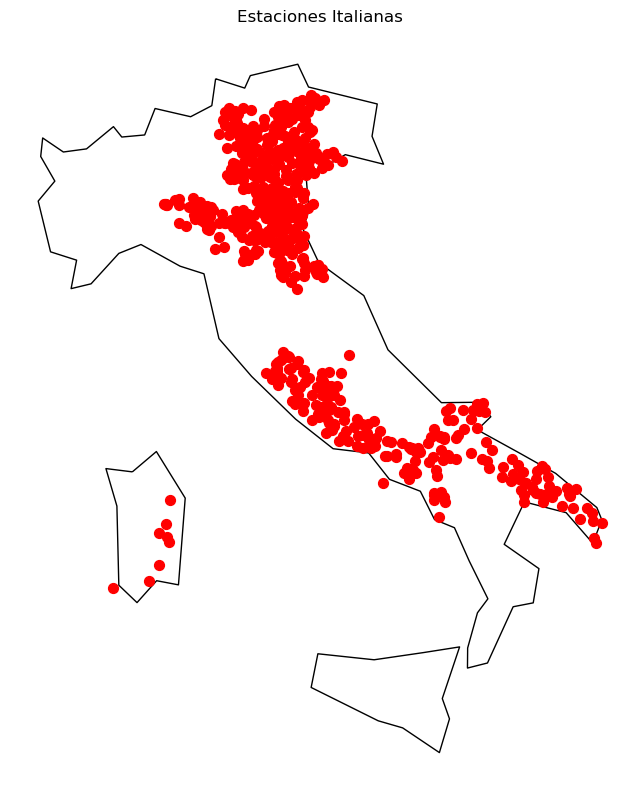

In [8]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas")
plt.axis("off")
plt.show()

In [9]:
#Lista de IDs de estaciones italianas
lista_estaciones_italianas=metadata_IT.STAID.to_list()

In [10]:
#Definición del dataframe con información de la primera estación
station='HU_STAID000000'
station_i=station[:-len(str(lista_estaciones_italianas[0]))]+str(lista_estaciones_italianas[0])
data=pd.read_csv('../Datos en bruto/Meteorologicos/Humedad/'+str(station_i)+'.txt',skiprows=20,sep=",")
data.columns=data.columns.str.strip()
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9) & (data.DATE<'2025-01-01')]
data_unif=data.loc[:,['DATE','HU']]
data_unif.set_index('DATE', inplace=True)
data_unif

,HU
DATE,
2008-01-01,75
2008-01-02,75
2008-01-03,87
2008-01-04,92
2008-01-05,97
...,...
2024-12-27,76
2024-12-28,69
2024-12-29,74


In [11]:
#Anexión de la información del resto de estaciones meteorológicas
for i in lista_estaciones_italianas[1:]:
    station='HU_STAID000000'
    station_i=station[:-len(str(i))]+str(i)
    data=pd.read_csv('../Datos en bruto/Meteorologicos/Humedad/'+station_i+'.txt',skiprows=20,sep=",")
    data.columns=data.columns.str.strip()
    data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
    data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
    df=data.loc[:,['DATE','HU']]
    df.set_index('DATE', inplace=True)
    data_unif['HU '+str(i)]=df

data_unif

,HU,HU 174,HU 175,HU 176,HU 177,HU 380,HU 861,HU 1733,HU 1736,HU 2768,...,HU 27892,HU 27893,HU 27895,HU 27896,HU 27899,HU 27900,HU 27902,HU 27904,HU 27905,HU 27906
DATE,,,,,,,,,,,,,,,,,,,,,
2008-01-01,75,76.0,73.0,58.0,76.0,NaN,NaN,71.0,69.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-02,75,70.0,77.0,60.0,80.0,NaN,NaN,66.0,68.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-03,87,70.0,80.0,64.0,79.0,NaN,NaN,87.0,75.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-04,92,76.0,84.0,64.0,98.0,NaN,NaN,95.0,89.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-05,97,86.0,78.0,80.0,98.0,NaN,NaN,99.0,92.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,76,NaN,NaN,NaN,51.0,63.0,NaN,79.0,44.0,56.0,...,70.0,17.0,25.0,34.0,29.0,25.0,29.0,82.0,76.0,42.0
2024-12-28,69,NaN,NaN,NaN,66.0,84.0,NaN,75.0,47.0,33.0,...,85.0,26.0,33.0,45.0,25.0,33.0,33.0,82.0,78.0,52.0
2024-12-29,74,NaN,NaN,NaN,76.0,83.0,NaN,85.0,61.0,34.0,...,87.0,34.0,41.0,47.0,34.0,38.0,43.0,83.0,84.0,43.0


In [12]:
# Se eliminan todas aquellas estaciones que tienen mas de un 2% de datos faltantes y se renombra la primera estación 
# con el ID de estación
d=data_unif.dropna(thresh=round(data_unif.shape[0]*0.98) ,axis=1)
d=d.rename({'HU':'HU '+str(lista_estaciones_italianas[0])},axis=1)
d

,HU 170,HU 17530,HU 17607,HU 17627,HU 17667,HU 17670,HU 17747,HU 17771,HU 17865,HU 17878,HU 25989,HU 26062,HU 26115,HU 26198,HU 26200,HU 26202,HU 26265,HU 26270,HU 27743
DATE,,,,,,,,,,,,,,,,,,,
2008-01-01,75,87.0,91,89,86,70.0,86,75,71.0,75,50.0,54.0,56.0,NaN,63.0,0.0,48.0,61.0,0.0
2008-01-02,75,85.0,75,80,82,71.0,82,75,66.0,75,55.0,49.0,66.0,NaN,NaN,0.0,82.0,53.0,0.0
2008-01-03,87,91.0,87,89,86,82.0,86,87,87.0,87,70.0,71.0,78.0,NaN,NaN,0.0,84.0,70.0,0.0
2008-01-04,92,95.0,92,93,90,89.0,90,92,95.0,92,72.0,71.0,97.0,NaN,NaN,0.0,86.0,100.0,0.0
2008-01-05,97,99.0,97,97,93,90.0,93,97,99.0,97,92.0,94.0,99.0,NaN,NaN,0.0,89.0,104.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,76,88.0,84,83,90,63.0,90,77,79.0,76,61.0,65.0,NaN,23.0,31.0,33.0,NaN,NaN,33.0
2024-12-28,69,87.0,80,78,86,62.0,86,75,75.0,69,61.0,55.0,NaN,41.0,45.0,47.0,NaN,NaN,47.0
2024-12-29,74,92.0,84,84,93,65.0,93,79,85.0,74,69.0,56.0,NaN,44.0,NaN,50.0,NaN,NaN,50.0


In [13]:
# Estaciones italianas sin valores faltantes
v=[]
for i in d.columns:
    v.append(int(i[3:]))
    
mt=metadata_IT[metadata_IT.STAID.isin(v)]
mt

,STAID,STANAME,CN,LAT,LON,HGHT
96,170,FERRARA,IT,44.832500,11.620833,15
2192,17530,BERRA,IT,44.967778,11.895556,3
2217,17607,DIAMANTINA,IT,44.885556,11.511667,5
2225,17627,GAIBANELLA,IT,44.768889,11.662500,3
2240,17667,MALBORGHETTO,IT,44.857778,11.660833,4
2242,17670,MARTORANO,IT,44.165833,12.267778,25
2269,17747,QUARTESANA,IT,44.818056,11.748889,2
2275,17771,SAN_BARTOLOMEO_IN_BOSCO,IT,44.741389,11.606389,8
2309,17865,RAVENNA_URBANA,IT,44.414444,12.200000,27
2313,17878,FERRARA_URBANA,IT,44.831944,11.620833,26


In [14]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt['LON'], mt['LAT'])] 
puntos = gpd.GeoDataFrame(mt, geometry=estaciones, crs="EPSG:4326") 

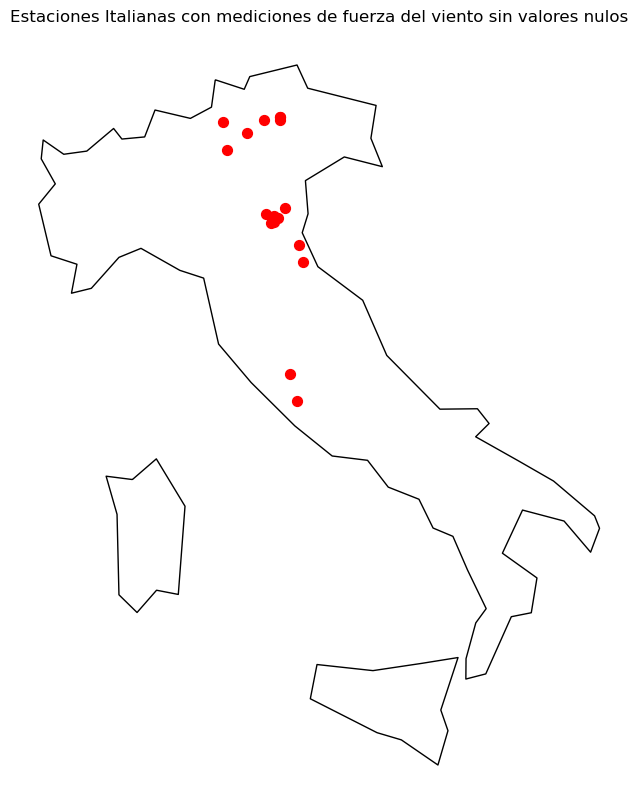

In [15]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas con mediciones de fuerza del viento sin valores nulos")
plt.axis("off")
plt.show()

In [16]:
#Primer filtrado de estaciones en función del valor truncado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt['LON'],mt['LAT'],mt['STAID']):
    if (math.trunc(x[0]),math.trunc(x[1])) not in w:
        w.append((math.trunc(x[0]),math.trunc(x[1])))
        ww.append(x[2])

mt_it=mt[mt.STAID.isin(ww)]

In [17]:
#Segundo filtrado de estaciones en función del valor redondeado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt_it['LON'],mt_it['LAT'],mt_it['STAID']):
    if (round(x[0]),round(x[1])) not in w:
        w.append((round(x[0]),round(x[1])))
        ww.append(x[2])
        
mt_IT=mt_it[mt_it.STAID.isin(ww)]
mt_IT

,STAID,STANAME,CN,LAT,LON,HGHT
96,170,FERRARA,IT,44.832500,11.620833,15
2242,17670,MARTORANO,IT,44.165833,12.267778,25
4597,25989,BRACCIANO,IT,42.073056,12.147778,251
4699,26115,CAVALESE,IT,46.284444,11.451667,958


In [18]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt_IT['LON'], mt_IT['LAT'])] 
puntos = gpd.GeoDataFrame(mt_IT, geometry=estaciones, crs="EPSG:4326") 

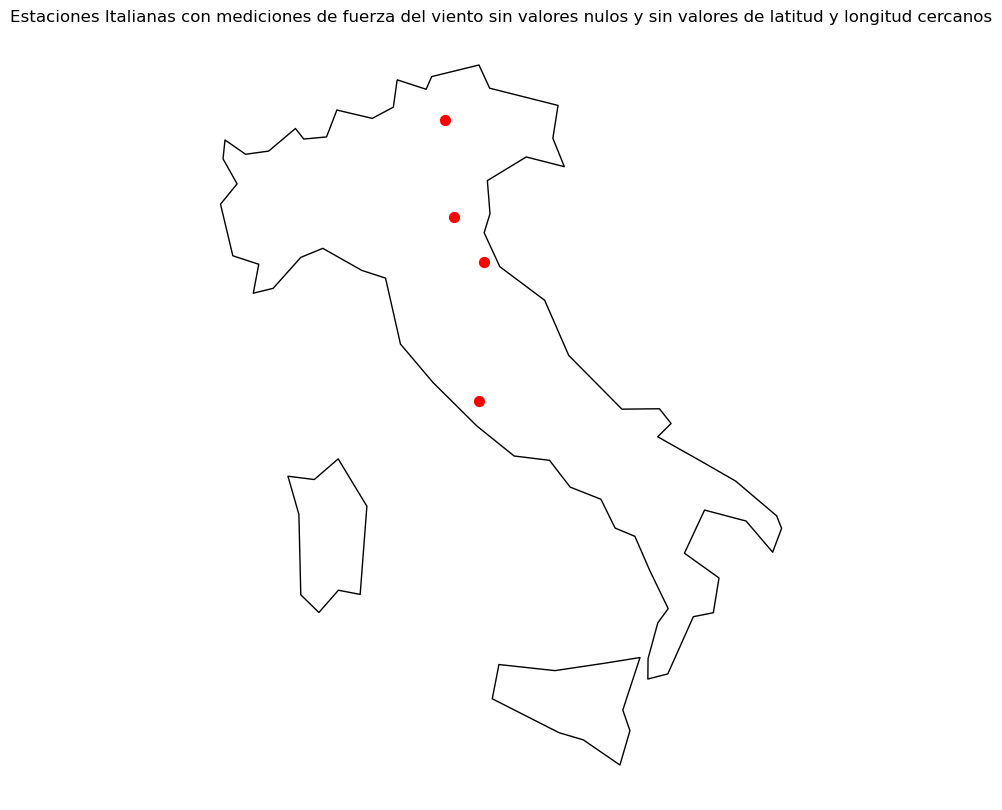

In [19]:
#Gráfica
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas con mediciones de fuerza del viento sin valores nulos y sin valores de latitud y longitud cercanos")
plt.axis("off")
plt.show()

In [20]:
#Agrupación de los datos diarios en datos semanales para cada estación
data=d.loc[:,['HU '+str(i) for i in mt_IT.STAID.to_list()]]
data=data.resample('MS').mean()
data

,HU 170,HU 17670,HU 25989,HU 26115
DATE,,,,
2008-01-01,87.064516,81.580645,84.566667,80.161290
2008-02-01,75.965517,76.000000,77.241379,67.931034
2008-03-01,71.064516,68.821429,88.741935,68.322581
2008-04-01,66.200000,64.933333,79.300000,74.300000
2008-05-01,64.483871,68.258065,76.806452,76.129032
...,...,...,...,...
2024-08-01,61.903226,67.225806,62.483871,68.193548
2024-09-01,66.800000,73.966667,72.400000,72.766667
2024-10-01,90.322581,87.193548,84.032258,86.967742


In [21]:
#Cálculo de la media para cada mes en función del total de estaciones
a=data.mean(axis=1)
a=pd.DataFrame(a).rename({0:'HU'},axis=1)
a

,HU
DATE,
2008-01-01,83.343280
2008-02-01,74.284483
2008-03-01,74.237615
2008-04-01,71.183333
2008-05-01,71.419355
...,...
2024-08-01,64.951613
2024-09-01,71.483333
2024-10-01,87.129032


In [24]:
#Exportación de datos mensuales de la humedad en Italia
a.to_csv('humedad_mensual_ita.csv',index=True,encoding='utf-8')

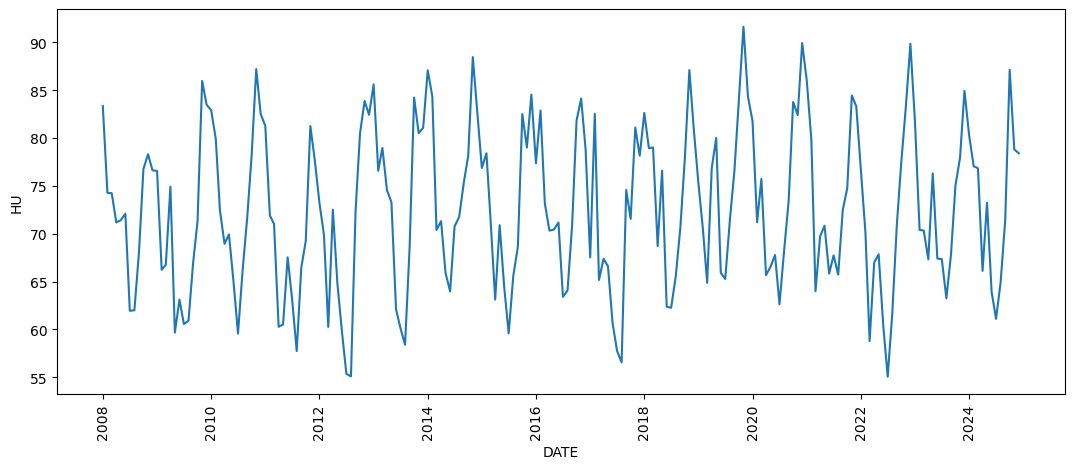

In [23]:
#Visualización de datos mensuales
plt.figure(figsize=(13,5))
sns.lineplot(data=a,x=a.index,y=a.HU)
plt.xticks(rotation=90)
plt.show()